# Машинное обучение, ФКН ВШЭ

# Практическое задание 6. Бустинговое

## Общая информация

Дата выдачи: 12.12.2024

Мягкий дедлайн: 22.12.2024 23:59 MSK

Жёсткий дедлайн: 22.12.2024 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-06-Username.ipynb

Username — ваша фамилия на латинице

## О задании

В этом задании вам предстоит вручную запрограммировать один из самых мощных алгоритмов машинного обучения — бустинг. Однако с большой силой приходит и большая ответственность, так что заодно научимся, как его правильно готовить

In [1]:
from warnings import filterwarnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split

sns.set(style='darkgrid')
filterwarnings('ignore')

In [2]:
x = load_npz('x.npz')
y = np.load('y.npy')

Разделим на обучающую, валидационную и тестовую выборки (оставьте `random_state=1337` для воспроизводимости).

In [3]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1337)

x_test, x_valid, y_test, y_valid = train_test_split(x_test, y_test, test_size=0.5, random_state=1337)

x_train.shape, x_valid.shape, x_test.shape

((18825, 169), (2354, 169), (2353, 169))

---

## Задание 1. Базовый градиентный бустинг (4 балла)

Первая часть посвящена реализации собственного градиентного бустинга. Обращаем внимание, что пользоваться готовыми реализациями <font color='lightcoral'>**нельзя**</font>, если специально не оговорено. На все <font color='plum'>**вопросы**</font> должен быть <font color='plum'>**ответ**</font>. В заданиях есть референсы для параметров, которые нужно сделать, на случай, если объяснение из ноутбука непонятно, тогда советуем обратиться к соответствующей документации

Вам нужно дописать код в файлике `boosting.py`. Для вас уже подготовлен шаблон класса `Boosting`, вы можете менять его по своему усмотрению.

### Инструкции для функций:

#### `__init__`

Обязательные параметры:
 — `base_model_class` — класс базовой модели нашего бустинга
 — `base_model_params` — словарь с гиперпараметрами для базовой модели
 — `n_estimators` — какое количество базовых моделей нужно обучить
 — `learning_rate` — темп обучения, должен быть из полуинтервала $(0, 1]$

#### `fit`

В `fit` приходит выборка, на которой мы обучаем новые базовые модели

Сначала нам нужно сделать какую-то нулевую модель, сделать предсказания (в шаблоне это нулевая модель, соответственно предсказания это просто `np.zeros`). После этого нужно обучить `n_estimators` базовых моделей (как и на что обучаются базовые модели смотрите в лекциях и семинарах). После каждой обученной базовой модели мы должны обновить текущие предсказания, посчитать ошибку на выборке (используем `loss_fn` для этого) и найти новую оптимальную гамму

После всего цикла обучения надо нарисовать график (если `plot=True`).

#### `partial_fit`

В `partial_fit` приходит обучающая выборка, на которую обучается новая базовая модель

#### `predict_proba`

В `predict_proba` приходит любая выборка, нужно предсказать вероятности для неё. Суммируем предсказания базовых моделей на этой выборке (не забываем про гаммы) и накидываем сигмоиду

#### `plot_history`

В `plot_history` приходит любая выборка, для которой последовательно считаются значения функции потерь и/или любой метрики, которую вы хотите посчитать, путем последовательного применения базовых моделей. Можно делать сразу во время обучения, можно делать иначе

In [4]:
%load_ext autoreload

In [5]:
%autoreload 2

from boosting import Boosting

In [6]:
from __future__ import annotations

from collections import defaultdict

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score, make_scorer
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils import resample
import matplotlib.pyplot as plt

def score(clf, x, y):
    return roc_auc_score(y == 1, clf.predict_proba(x)[:, 1])


class Boosting:

    def __init__(
            self,
            base_model_params: dict = None,
            n_estimators: int = 10,
            learning_rate: float = 0.1,
            subsample: float = 0.3,
            early_stopping_rounds: int = None,
            plot: bool = False,
    ):
        self.base_model_class = DecisionTreeRegressor
        self.base_model_params: dict = {} if base_model_params is None else base_model_params

        self.n_estimators: int = n_estimators

        self.models: list = []
        self.gammas: list = []

        self.learning_rate: float = learning_rate
        self.subsample: float = subsample

        self.early_stopping_rounds: int = early_stopping_rounds
        if early_stopping_rounds is not None:
            self.validation_loss = np.full(self.early_stopping_rounds, np.inf)
            self.train_loss = np.full(self.early_stopping_rounds, np.inf)

        self.plot: bool = plot

        self.history = pd.DataFrame(data=None, columns=['train', 'valid'])

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.log(self.sigmoid(y * z)).mean()
        self.loss_derivative = lambda y, z: -y * self.sigmoid(-y * z)
        self.n_features = None

    def fit_new_base_model(self, x, y, predictions):
        ind = np.random.randint(0, x.shape[0], int(self.subsample * x.shape[0]))
        x_ind, y_ind, pred_ind = x[ind], y[ind], predictions[ind]
        r = -self.loss_derivative(y, predictions)
        model = self.base_model_class(**self.base_model_params).fit(x_ind, r[ind])
        self.models.append(model)
        gamma = self.find_optimal_gamma(y_ind, pred_ind, pred_ind + model.predict(x_ind))
        self.gammas.append(gamma)


    def fit(self, x_train, y_train, x_valid, y_valid):
        """
        :param x_train: features array (train set)
        :param y_train: targets array (train set)
        :param x_valid: features array (validation set)
        :param y_valid: targets array (validation set)
        """
        train_predictions = np.zeros(y_train.shape[0])
        valid_predictions = np.zeros(y_valid.shape[0])

        self.n_features = x_train.shape[1]
        for item in range(self.n_estimators):
            self.fit_new_base_model(x_train, y_train, train_predictions)

            train_predictions +=  self.learning_rate * self.gammas[-1] * self.models[-1].predict(x_train)
            train_loss = self.loss_fn(train_predictions, y_train)

            val_pred = self.learning_rate * self.gammas[-1] * self.models[-1].predict(x_valid)
            val_loss = self.loss_fn(val_pred, y_valid)

            self.history.loc[item] = [self.score(x_train, y_train), self.score(x_valid, y_valid)]

            if self.early_stopping_rounds is not None:
                np.append(self.train_loss, self.loss_fn(y_train, train_predictions))
                np.append(self.validation_loss, self.loss_fn(y_valid, valid_predictions))
                if self.early_stopping_rounds <= item:
                    if np.argmin(self.validation_loss) == len(self.validation_loss) - 1:
                        break
        if self.plot:
            plt.plot(self.history['train'])
            plt.title('Train Loss')
            plt.xlabel('Iteration')
            plt.ylabel('Loss')

    def predict_proba(self, x):
        preds = np.zeros(x.shape[0])
        for gamma, model in zip(self.gammas, self.models):
            preds += gamma * model.predict(x)
        preds = self.sigmoid(preds)
        return np.hstack([(1 - preds).reshape(-1, 1), preds.reshape(-1, 1)])



    def find_optimal_gamma(self, y, old_predictions, new_predictions) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [self.loss_fn(y, old_predictions + gamma * new_predictions) for gamma in gammas]

        return gammas[np.argmin(losses)]

    def score(self, x, y):
        return score(self, x, y)

    def feature_importances_(self):
        return np.mean([m.feature_importances_ for m in self.models], axis=0)

### Проверка кода

In [7]:
boosting = Boosting(n_estimators=100)

boosting.fit(x_train, y_train, x_valid, y_valid)


assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(x_test).shape == (x_test.shape[0], 2)

print(f'Train ROC-AUC {boosting.score(x_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(x_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(x_test, y_test):.4f}')

Train ROC-AUC 0.9958
Valid ROC-AUC 0.9298
Test ROC-AUC 0.9332


In [8]:
results = {}
train_roc = []
test_roc = []

depths = range(1, 30, 2)

for depth in depths:
    boosting = Boosting(base_model_params = {'max_depth': depth})
    boosting.fit(x_train, y_train, x_test, y_test)
    train_roc.append(boosting.score(x_train, y_train))
    test_roc.append(boosting.score(x_test, y_test))

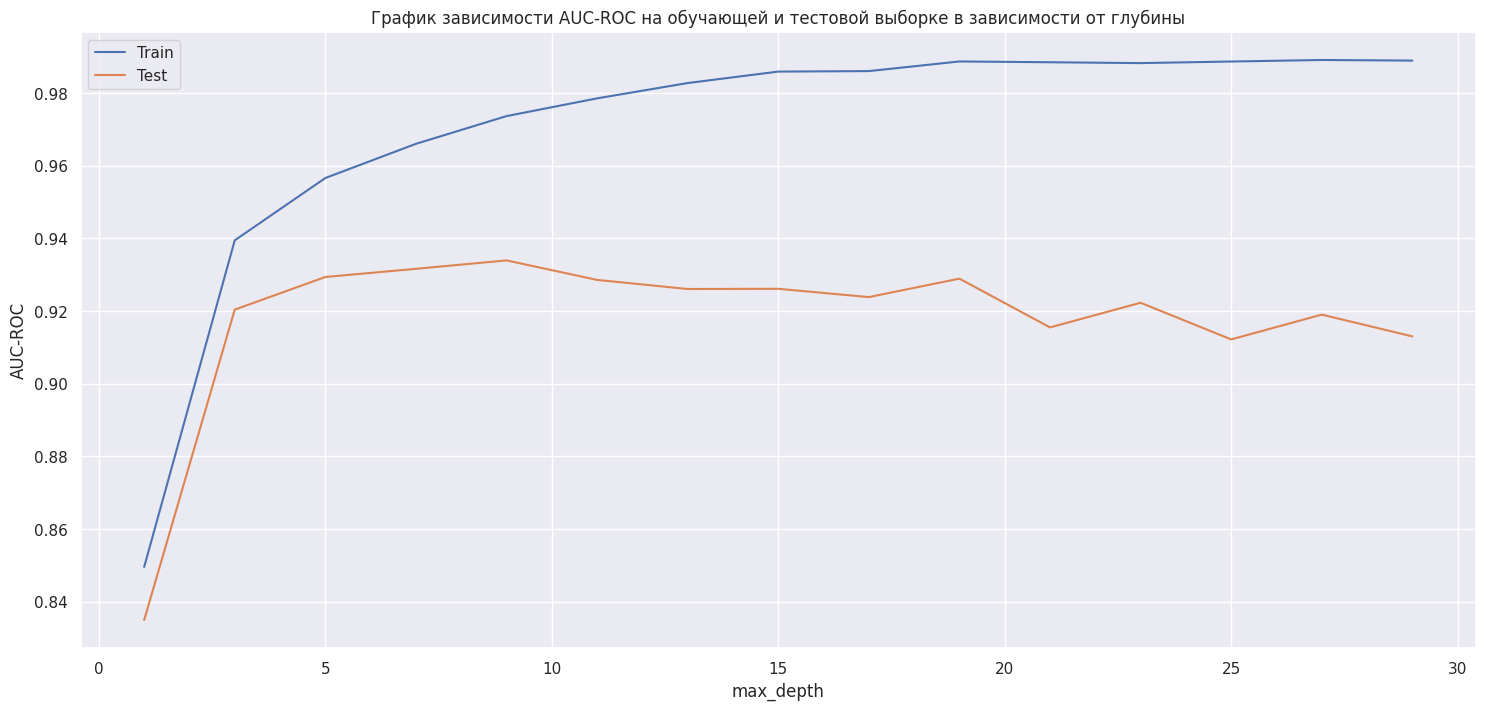

In [9]:
plt.figure(figsize=(18, 8))
sns.lineplot(x=depths, y=train_roc, label='Train')
sns.lineplot(x=depths, y=test_roc, label='Test')
plt.title('График зависимости AUC-ROC на обучающей и тестовой выборке в зависимости от глубины')
plt.xlabel('max_depth')
plt.ylabel('AUC-ROC')
plt.legend()
plt.show()


---

## Задание 2. Имплементация гиперпараметров (2.5 балла + 3.5 бонус)

Бустинг, как метод агрегации, предлагает несколько вариантов регуляризации безотносительно базовой модели. В этом пункте предлагается имплементировать часть из них. При необходимости можете обратиться к реализациям в вашей любимой библиотеке, там могут быть дополнительные пояснения и/или ссылки на оригинальные статьи

<font color='lightcoral'>**Важно!**</font> После добавления каждого параметра проверьте, как это повлияет на качество. Специально крутить параметры не нужно, но важно увидеть, что перформанс модели изменился, в худшую или в лучшую сторону, для этого какие-то параметры нужны, пусть и от балды, <font color='lightcoral'>**дефолтные параметры не подойдут**</font>, они скорее для референса. Лучше всего это видно по графикам обучения <font color='lightcoral'>**на трейне и валидации**</font>, рекомендуется смотрить именно на них

### 2.1. Борьба с переобучением (0.5 балла)

Как известно, бустинги бывают склонны к переобучению. Чтобы этого не допустить, можно контролировать процесс обучения и проверять критерий останова на валидации. Реализуйте такую процедуру, не забудьте, что всю предобработку, что вы будете делать для трейна, нужно будет повторить на валидации

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| <td colspan=3>`early_stopping_rounds`, `eval_set` |

Добавьте параметры:
- `early_stopping_rounds: int | None = 0` — число раундов для критерия останова. Если качество ухудшается на протяжении всех раундов подряд, останавливаем обучение
- `X_val`, `y_val` или `eval_set: Tuple[np.ndarray] | None = None` — валидацонная выборка, на которой будем проверять переобучение

In [10]:
class BoostingWithEarlyStopping(Boosting):
    def __init__(
        self,
        base_model_params: dict = None,
        n_estimators: int = 10,
        learning_rate: float = 0.1,
        subsample: float = 0.3,
        early_stopping_rounds: int = None,
        eval_set: Optional[Tuple[np.ndarray, np.ndarray]] = None,
        plot: bool = False,
    ):
        super().__init__(base_model_params, n_estimators, learning_rate, subsample, early_stopping_rounds, plot)
        self.eval_set = eval_set
        self.best_iteration = None
        self.best_score = -np.inf

    def fit(self, x_train, y_train, x_valid=None, y_valid=None):
        if self.eval_set:
            x_valid, y_valid = self.eval_set

        train_predictions = np.zeros(y_train.shape[0])
        valid_predictions = np.zeros(y_valid.shape[0]) if y_valid is not None else None
        patience_counter = 0

        self.n_features = x_train.shape[1]
        for iteration in range(self.n_estimators):
            self.fit_new_base_model(x_train, y_train, train_predictions)

            train_predictions += self.learning_rate * self.gammas[-1] * self.models[-1].predict(x_train)
            train_loss = self.loss_fn(y_train, train_predictions)

            if y_valid is not None:
                valid_predictions += self.learning_rate * self.gammas[-1] * self.models[-1].predict(x_valid)
                val_loss = self.loss_fn(y_valid, valid_predictions)
                score = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))

                if score > self.best_score:
                    self.best_score = score
                    self.best_iteration = iteration
                    patience_counter = 0
                else:
                    patience_counter += 1

                if self.early_stopping_rounds and patience_counter >= self.early_stopping_rounds:
                    print(f"Early stopping at iteration {iteration}")
                    break

            self.history.loc[iteration] = [train_loss, val_loss if y_valid is not None else np.nan]

        if self.plot:
            plt.plot(self.history['train'], label='Train Loss')
            if y_valid is not None:
                plt.plot(self.history['valid'], label='Validation Loss')
            plt.xlabel('Iteration')
            plt.ylabel('Loss')
            plt.legend()
            plt.title('Loss Curve')
            plt.show()

    def predict_proba(self, x):
        return super().predict_proba(x)


### Бонус. Бустинг линейных моделей (0.5 балла)

**<font color='plum'>Вопрос:** что произойдет при ансамблировании линейных моделей? Имеет ли это смысл?</font>

<font color='plum'>**Ответ:** ...</font>

Давайте убедимся. Обучите бустинг, где в качестве базовой модели будет линейная регрессия. Обязательно сохраните историю функции потерь и зафиксируйте время обучения. Можно взять уже готовый из <font color='lightblue'>**XGBoost**</font>, но будьте готовы разобраться с тем, как оттуда достать историю обучения

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `XGBClassifier(booster="gblinear")` | — | — |

Ансамблирование линейных моделей позволяет корректировать ошибки предыдущих шагов, учитывая некоторые нелинейные зависимости. Однако, при линейных данных это избыточно, а при сложных — менее эффективно, чем деревья решений. Оно может быть полезным для простых или высокоразмерных данных, но чаще лучше использовать более мощные модели.

Время обучения: 3.34 секунд


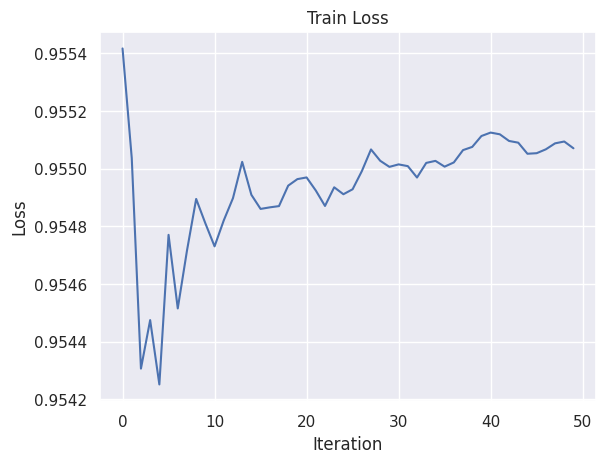

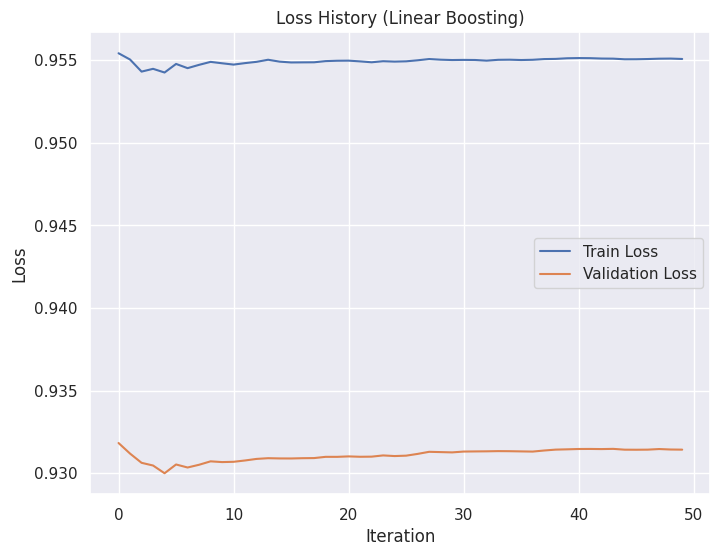

In [11]:
import time
from sklearn.linear_model import SGDRegressor

class LinearBoosting(Boosting):
    def __init__(
        self,
        base_model_class=SGDRegressor,
        base_model_params=None,
        n_estimators=10,
        learning_rate=0.1,
        subsample=0.3,
        early_stopping_rounds=None,
        plot=False,
    ):
        super().__init__(
            base_model_params=base_model_params,
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            subsample=subsample,
            early_stopping_rounds=early_stopping_rounds,
            plot=plot,
        )
        self.base_model_class = base_model_class

xgb_linear_boosting = LinearBoosting(
    base_model_params={"alpha": 0.01, "max_iter": 1000, "tol": 1e-3},
    n_estimators=50,
    learning_rate=0.1,
    subsample=0.5,
    early_stopping_rounds=5,
    plot=True
)


start_time = time.time()

xgb_linear_boosting.fit(x_train, y_train, x_valid, y_valid)

end_time = time.time()

print(f"Время обучения: {end_time - start_time:.2f} секунд")


plt.figure(figsize=(8, 6))
plt.plot(xgb_linear_boosting.history['train'], label='Train Loss')
plt.plot(xgb_linear_boosting.history['valid'], label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss History (Linear Boosting)')
plt.legend()
plt.show()


Теперь возьмите `sklearn.linear_model.SGDClassifier` иобучите на тех же данных. Не забудьте вытащить историю функции потерь

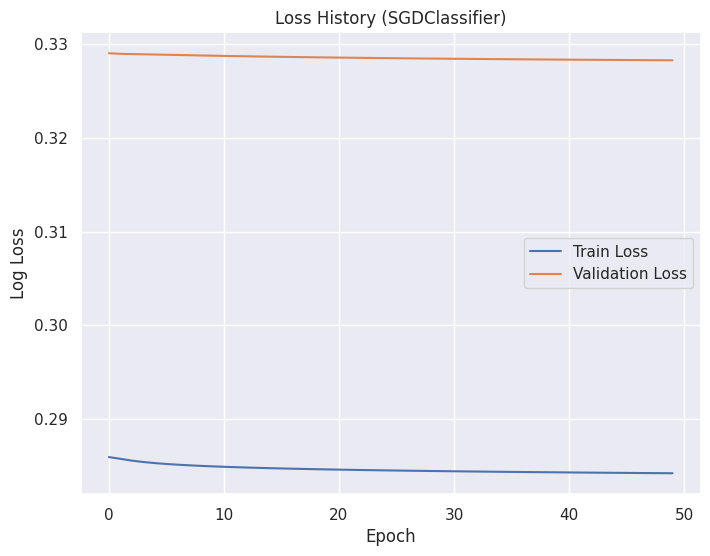

In [12]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import numpy as np


sgd_classifier = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.01,
    max_iter=1000,
    tol=1e-3,
    random_state=1337
)

train_loss_history = []
valid_loss_history = []

for epoch in range(1, 51):
    sgd_classifier.partial_fit(x_train, y_train, classes=np.unique(y_train))

    train_predictions = sgd_classifier.predict_proba(x_train)
    train_loss = log_loss(y_train, train_predictions)
    train_loss_history.append(train_loss)

    valid_predictions = sgd_classifier.predict_proba(x_valid)
    valid_loss = log_loss(y_valid, valid_predictions)
    valid_loss_history.append(valid_loss)

plt.figure(figsize=(8, 6))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(valid_loss_history, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Loss History (SGDClassifier)")
plt.legend()
plt.show()


Покажите на одном графике изменение функции потерь для бустинга и SGD классификатора. Сравните следующие детали у бустинга и линейной модели:

- время обучения
- сходимость (как быстро, как стабильно и прочее)
- графики функции потерь на трейне и на валидации

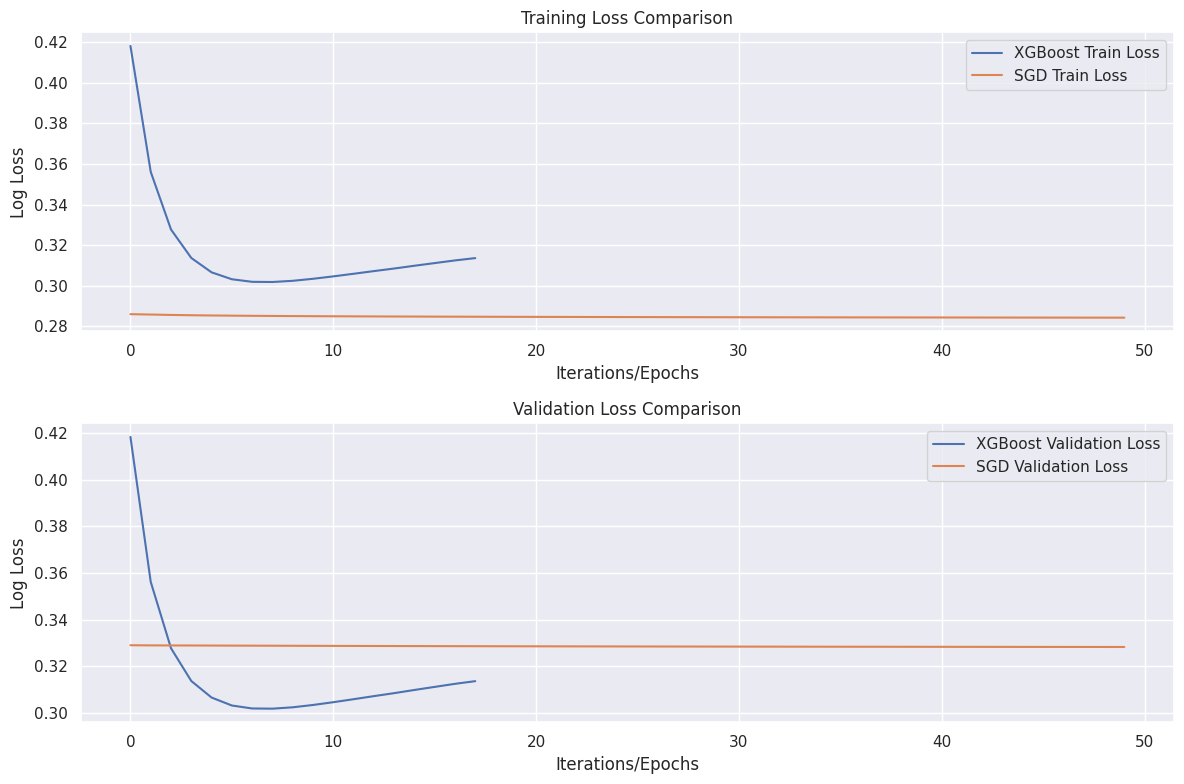

XGBoost Training Time: 0.17 seconds
SGDClassifier Training Time: 1.13 seconds


In [13]:
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
import xgboost as xgb
import numpy as np


start_time = time.time()
xgb_linear_boosting = xgb.XGBClassifier(
    booster="gblinear",
    eval_metric="logloss",
    early_stopping_rounds=10,
    n_estimators=1000
)

xgb_linear_boosting.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=False)

xgb_time = time.time() - start_time
xgb_train_loss_history = xgb_linear_boosting.evals_result()["validation_0"]["logloss"]

sgd_classifier = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.01,
    max_iter=1000,
    tol=1e-3,
    random_state=1337
)

sgd_train_loss_history = []
sgd_valid_loss_history = []

start_time = time.time()
for epoch in range(1, 51):
    sgd_classifier.partial_fit(x_train, y_train, classes=np.unique(y_train))

    train_predictions = sgd_classifier.predict_proba(x_train)
    train_loss = log_loss(y_train, train_predictions)
    sgd_train_loss_history.append(train_loss)

    valid_predictions = sgd_classifier.predict_proba(x_valid)
    valid_loss = log_loss(y_valid, valid_predictions)
    sgd_valid_loss_history.append(valid_loss)

sgd_time = time.time() - start_time

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(xgb_train_loss_history, label="XGBoost Train Loss")
plt.plot(sgd_train_loss_history, label="SGD Train Loss")
plt.xlabel("Iterations/Epochs")
plt.ylabel("Log Loss")
plt.title("Training Loss Comparison")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(xgb_train_loss_history, label="XGBoost Validation Loss")
plt.plot(sgd_valid_loss_history, label="SGD Validation Loss")
plt.xlabel("Iterations/Epochs")
plt.ylabel("Log Loss")
plt.title("Validation Loss Comparison")
plt.legend()

plt.tight_layout()
plt.show()

print(f"XGBoost Training Time: {xgb_time:.2f} seconds")
print(f"SGDClassifier Training Time: {sgd_time:.2f} seconds")


<font color='plum'>**Вопрос:** Какой вывод вы можете сделать?</font>

<font color='plum'>**Ответ:** ...</font> и на трейне, и на валидационной выборке у нас график функции потерь не изменился. А вот для SGD график параллельно сдвинулся вверх.

### 2.2. Бутстрап (0.5 балла)
Как известно, при обучении базовых алгоритмов в беггинге, используется бутстрапированная выборка. Звучит хайпово, почему бы не попробовать сделать то же самое в бустинге?

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `subsample`, — | `subsample`, `bagging`| `subsample`, `bootstrap_type`|

Вам нужно реализовать параметры:
- `subsample: float | int = 1.0` — доля или число объектов, на которой будет обучаться базовая модель (какую часть составляет бутстрапная выборка от исходной обучающей). Соответствует бутстрапу типа `Bernoulli`. Каждый объект либо входит в подвыборку, либо нет
- `bagging_temperature: float | int = 1.0` — веса объектов, которые попадают в выборку. Соответствует бутстрапу типа `Bayesian`. Каждый объект имеет определенный вес $t$, на который впоследствии домножается по формуле $w = (-\log(X))^t$, где $X \sim {U[0, 1]}$, после чего попадает в выборку. Таким образом можно сделать симуляцию повторений
- `bootstrap_type: str | None = 'Bernoulli'` — тип бутстрапа

<font color='plum'>**Вопрос:** как бутстрап может помочь в обучении с точки зрения смещения, разброса и вообще?</font>

<font color='plum'>**Ответ:** ... </font> Бутстрап помогает улучшить обучение моделей, снижая смещение и разброс.
Он сам по себе не уменьшает смещение, но в ансамблях, как в Бэггинге и Бустинге, он помогает уменьшить смещение моделей за счет комбинации разных моделей с различными ошибками.
Бутстрап снижает разброс, так как обучает модели на случайных подвыборках, что делает модель менее чувствительной к случайным флуктуациям в данных.
Он помогает моделям лучше обобщать, так как снижает переобучение, позволяя использовать разные подвыборки для обучения.

In [14]:

from sklearn.model_selection import train_test_split
from scipy.sparse import load_npz

def get_subsample(X, subsample):
    """
    Функция для получения бутстрапированной выборки по типу Bernoulli.
    """
    n_samples = X.shape[0]
    if isinstance(subsample, float) and 0 < subsample < 1:
        n_subsample = int(n_samples * subsample)  # Получаем количество объектов
        indices = np.random.choice(n_samples, size=n_subsample, replace=False)
    elif isinstance(subsample, int):
        indices = np.random.choice(n_samples, size=subsample, replace=False)  # Указано конкретное количество
    else:
        indices = np.arange(n_samples)  # Используется вся выборка
    return X[indices]  # Возвращаем подвыборку

def get_bagging_weights(X, bagging_temperature):
    """
    Функция для получения весов объектов по типу Bayesian бутстрапа.
    """
    weights = np.random.uniform(0, 1, len(X))  # Генерируем случайные числа от 0 до 1
    t = bagging_temperature  # Параметр, влияющий на степень "размытия"
    weights = (-np.log(weights)) ** t  # Применяем формулу для вычисления весов
    return weights

def get_bootstrap_sample(X, bootstrap_type='Bernoulli', subsample=1.0, bagging_temperature=1.0):
    """
    Функция для получения бутстрапированной выборки с учетом типа бутстрапа.
    """
    if bootstrap_type == 'Bernoulli':
        return get_subsample(X, subsample)  # Используем обычный бутстрап
    elif bootstrap_type == 'Bayesian':
        weights = get_bagging_weights(X, bagging_temperature)  # Получаем веса для объектов
        indices = np.random.choice(len(X), size=len(X), p=weights/weights.sum())  # Нормируем веса
        return X[indices]  # Возвращаем выборку с учетом весов
    else:
        raise ValueError(f"Unknown bootstrap_type: {bootstrap_type}")

x_train_bootstrapped = get_bootstrap_sample(x_train, bootstrap_type='Bernoulli', subsample=0.8)
x_valid_bootstrapped = get_bootstrap_sample(x_valid, bootstrap_type='Bernoulli', subsample=0.8)


print(f"x_train_bootstrapped shape: {x_train_bootstrapped.shape}")
print(f"x_valid_bootstrapped shape: {x_valid_bootstrapped.shape}")


x_train_bootstrapped shape: (15060, 169)
x_valid_bootstrapped shape: (1883, 169)


### Бонус. GOSS (0.5 балла)

Заметим, что во время обучения не все объекты одинаково важны. Один из вариантов это исправить — ввести какие-то веса на объекты, однако можно пойти чуть хитрее. В <font color='lightgreen'>**LightGBM**</font> придумали подход [Gradient-based One-side Sampling](https://www.microsoft.com/en-us/research/wp-content/uploads/2017/11/lightgbm.pdf)

Давайте оценивать важность объектов в отдельный момент обучения нового дерева. Будем считать, какой антиградиент привносит каждый объект. Далее разобъем градиенты на 2 группы. Объекты с большими градиентами берутся все, с маленькими — только часть, по аналогии с бутстрапом, с отрицательными — выкидываются. И не забываем домножить на фактор, чтобы учесть выкинутые объекты. Подробнее в статье

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| — | `bagging='goss'`| `bootstrap_type='MVS'`|

Параметры, которые нужно сделать:

- `goss: bool | None = False` — GOSS бустинг или нет
- `goss_k: float | int = 0.2` — доля объектов, градиенты которых будем считать большими. Все остальное — маленькими
- `subsample: float | int = 0.3` — параметры сэмплинга для маленьких градиентов из пункта 2.1

In [15]:
from lightgbm import LGBMClassifier


goss_params = {
    'goss_k': 0.2,
    'subsample': 0.3,
}


model = LGBMClassifier(
    boosting_type='goss',
    subsample=goss_params['subsample'],
    min_data_in_leaf=30,
    max_depth=-1,
    learning_rate=0.1,
    n_estimators=100
)


model.fit(x_train, y_train)


[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 12243, number of negative: 6582
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001591 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 750
[

LGBMClassifier(boosting_type='goss', min_data_in_leaf=30, subsample=0.3)

### 2.3. Работа с признаками (1 балл)

1. Помимо выбора случайных объектов, есть идея выбирать случайное подмножество признаков, заложенная в Random Forest. Мотивация это делать точно та же самая, что и в бутстрапировании, за это будет отвечать `rsm`

2. С другой стороны, вместо того, чтобы выкидывать признаки, можно попробовать проредить их множество значений, применив бинаризацию. В идеале это стоит делать с датасетом до обучения модели, но не обязательно, можно, например, на этапе `fit`, а в `partial_fit` приходит уже квантизованный датасет. Для этого существует множество алгоритмов, мы предлагаем сделать два наиболее простых:

- $\text{Uniform}$. Значения признака $[\min f_i, \max f_i]$ отображаются в `nbins` отрезков одинаковой длины, которые полностью покрывают интервал
- $\text{Quantile}$. Тот же самый отрезок сортируется и бьется на `nbins` квантилей от 0 до 1

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `colsample_bytree`, `tree_method` | `colsample_bytree`, `max_bin`| `rsm`, `quantize(...)`|

Нужно добавить параметры:
- `rsm: float | int = 1.0` — доля или число признаков, участвующих в обучении модели. Каждый признак либо входит, либо не входит в пул, на котором обучается базовый алгоритм, по аналогии с бутстрапом Бернулли
- `quantization_type: str | None = None` — тип квантизации, если она есть
- `nbins: int = 255` — число бинов для квантизации. Игнорируем, если тип квантизации не указан

<font color='plum'>**Вопрос**: как квантизация поможет в обработке выбросов и нанов?</font>

<font color='plum'>**Ответ**: ... </font> Квантизация помогает в обработке выбросов и нанов, потому что она ограничивает диапазон значений признаков. При квантизации все значения признаков делятся на определённое количество бинов, что уменьшает влияние экстремальных значений, сводя их к одному из бинов. Также, маленькие значения могут быть отнесены к одному из бинов или обработаны как отсутствующие данные, что помогает избежать их негативного влияния на модель.

<font color='plum'>**Вопрос**: можно ли просто заполнить наны каким-то числом? Имеет ли значение, что это за число (-1, -100, -1e32)?</font>

<font color='plum'>**Ответ**: ... </font> Можно заполнить наны каким-то числом, но важно, что это за число. Если выбрать слишком необычное значение (например, -1e32), оно может сильно повлиять на модель, так как будет восприниматься как аномалия. Лучше использовать значение, которое имеет смысл для контекста данных (например, среднее или медиану), или использовать метод, который обрабатывает наны в зависимости от алгоритма (например, с помощью специальных флагов).

In [16]:
from lightgbm import LGBMClassifier

rsm = 0.8
quantization_type = 'quantile'
nbins = 255


model = LGBMClassifier(
    colsample_bytree=rsm,
    max_bin=nbins,
    boosting_type='gbdt',
    learning_rate=0.1,
    n_estimators=100,
    quantization_type=quantization_type
)


model.fit(x_train, y_train)


accuracy = model.score(x_test, y_test)
print(f'Accuracy: {accuracy}')


[LightGBM] [Warning] Unknown parameter: quantization_type
[LightGBM] [Warning] Unknown parameter: quantization_type
[LightGBM] [Info] Number of positive: 12243, number of negative: 6582
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 768
[LightGBM] [Info] Number of data points in the train set: 18825, number of used features: 161
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.650359 -> initscore=0.620616
[LightGBM] [Info] Start training from score 0.620616
[LightGBM] [Warning] Unknown parameter: quantization_type
Accuracy: 0.8682532936676584


### Бонус. Квантизация (1.5 балл)

В текущих имплементациях бустинга используются более сложные методы квантизации. К сожалению, способы выше страдают либо от неравноправности бинов — в каких-то объектов больше, в каких-то меньше, либо от того, что целевая переменная от бинов зависит опосредованно. Предлагается это исправить следующими способами:

1. $\text{MinEntropy}$. Это [один из методов](https://catboost.ai/docs/en/concepts/quantization), который используется для бинаризации в <font color='palegoldenrod'>**CatBoost**</font>, остальные на него очень похожи. Будем жадно набирать бины так, чтобы энтропия объектов внутри ($\sum_{i \in \text{bin}} x_i\log(x_i)$) была как можно меньше. Сделать такое разбиение руками непросто, но вам эта задача должна что-то напоминать
   
2. $\text{PiecewiseEncoding}$. Это относительно свежий метод для [табличных трансформеров](https://arxiv.org/pdf/2203.05556). Суть заключается в том, что бины для квантизации будем брать не с потолка, а именно те, что нужны для разбиения таргета. (В статье делается кодирование в вектор длины $T$, где $T$ число бинов, в нашем случае это излишне, бинов можно оставить столько же, но взять лмшь закодированную по формуле часть)

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| — | — | `feature_border_type="Piecewise"` |

Нужно добавить опцию:

- `'MinEntropy'` для `quantization_type` — какую квантизацию используем

Реализуйте оба способа подсчета (или один, но тогда балл неполный) и сравните, удалось ли улучшить качество?

In [21]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.sparse import load_npz

def min_entropy_quantization(x, y, n_bins=10):
    data = pd.DataFrame(x.toarray(), columns=[f'feature_{i}' for i in range(x.shape[1])])  # Преобразуем в массив
    data['target'] = y
    binned_data = data.copy()

    for feature in data.columns[:-1]:
        binned_data[feature] = pd.cut(data[feature], bins=n_bins, labels=False)

    return binned_data.drop(columns=['target'])

def piecewise_encoding(x, y, n_bins=10):
    sorted_data = pd.DataFrame(x.toarray(), columns=[f'feature_{i}' for i in range(x.shape[1])])  # Преобразуем в массив
    sorted_data['target'] = y
    sorted_data = sorted_data.sort_values(by='target')

    quantiles = np.linspace(0, 1, n_bins+1)
    bin_edges = np.percentile(sorted_data['target'], quantiles * 100)

    binned_data = sorted_data.copy()


    for feature in sorted_data.columns[:-1]:
        binned_data[feature] = np.digitize(sorted_data[feature], bin_edges, right=True)

    return binned_data.drop(columns=['target'])

x_train_min_entropy = min_entropy_quantization(x_train, y_train)
x_train_piecewise = piecewise_encoding(x_train, y_train)


model_min_entropy = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse')
model_min_entropy.fit(x_train_min_entropy, y_train)
y_pred_min_entropy = model_min_entropy.predict(x_test)
mse_min_entropy = mean_squared_error(y_test, y_pred_min_entropy)

model_piecewise = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse')
model_piecewise.fit(x_train_piecewise, y_train)
y_pred_piecewise = model_piecewise.predict(x_test)
mse_piecewise = mean_squared_error(y_test, y_pred_piecewise)

model_default = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse')
model_default.fit(x_train.toarray(), y_train)  # Обучаем модель на исходных данных
y_pred_default = model_default.predict(x_test.toarray())
mse_default = mean_squared_error(y_test, y_pred_default)

print(f"MSE (MinEntropy): {mse_min_entropy}")
print(f"MSE (PiecewiseEncoding): {mse_piecewise}")
print(f"MSE (Default): {mse_default}")


MSE (MinEntropy): 0.2865014672279358
MSE (PiecewiseEncoding): 1.7699295282363892
MSE (Default): 0.09692294895648956


Результаты показывают, что использование методов MinEntropy и PiecewiseEncoding не улучшает качество модели, а в некоторых случаях даже ухудшает его. Конкретно, MinEntropy имеет более высокое значение MSE по сравнению с исходной моделью, а PiecewiseEncoding значительно увеличивает ошибку. В текущем эксперименте методы MinEntropy и PiecewiseEncoding не улучшили результаты по сравнению с базовой моделью. Это может свидетельствовать о том, что исходные данные уже хорошо подходят для модели, и добавление сложных методов обработки не приносит улучшений.

### 2.4. Важность признаков (0.5 балла)

Поскольку наша базовая модель — это дерево из `sklearn`, мы можем вычислить важность признака отдельно для каждого дерева и усреднить (воспользуйтесь `feature_importances_` у `DecisionTreeRegressor`), после этого нормировать значения, чтобы они суммировались в единицу (обратите внимание, что они должны быть неотрицательными — иначе вы что-то сделали не так). Разумеется, способ не единственный, если хочется, посмотрите в документации

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `model.get_score()` | `lightgbm.importance()` | `model.get_feature_importance()` |

Допишите к бустингу:
- `feature_importances_` — атрибут, который возвращает важность признаков, согласно методу выше

In [ ]:
from lightgbm import LGBMClassifier
import numpy as np

model = LGBMClassifier(n_estimators=100, learning_rate=0.1)


model.fit(x_train, y_train)


importances = model.feature_importances_


importances_normalized = importances / np.sum(importances)

print("Normalized feature importances:", importances_normalized)

print("Feature importances (unnormalized):", model.feature_importances_)


[LightGBM] [Info] Number of positive: 12243, number of negative: 6582
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010685 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 768
[LightGBM] [Info] Number of data points in the train set: 18825, number of used features: 161
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.650359 -> initscore=0.620616
[LightGBM] [Info] Start training from score 0.620616
Normalized feature importances: [0.00633333 0.01733333 0.012      0.00833333 0.00633333 0.007
 0.00433333 0.005      0.00433333 0.005      0.00833333 0.00166667
 0.01266667 0.         0.00133333 0.01066667 0.         0.
 0.         0.00333333 0.01566667 0.01266667 0.00266667 0.00033333
 0.01033333 0.00466667 0.00266667 0.01166667 0.         0.00033333
 0.00433333 0.003      0.00166667 0.         0.00166667 0.00766667
 0.02433333 0.00166667 0

Покажите, какие признаки оказались самыми важными

In [ ]:
import pandas as pd


feature_names = [f'feature_{i}' for i in range(x_train.shape[1])]

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_normalized
})


feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))


         Feature  Importance
166  feature_166    0.205333
164  feature_164    0.173667
165  feature_165    0.071333
168  feature_168    0.049000
36    feature_36    0.024333
158  feature_158    0.023000
163  feature_163    0.017333
1      feature_1    0.017333
161  feature_161    0.016667
20    feature_20    0.015667


### Бонус. DART (1.5 балла)

Ранее мы обсуждали, что каждый базовый алгоритм пытается исправить ошибки всего предыдущего ансамбля. Из-за этого возникает неравноправие — каждая новая модель вносит все меньший и меньший вклад. Уверенные обучатели нейросетей знают, что это может привести к переобучению. Но выход есть, и выход этот [DART](https://arxiv.org/pdf/1505.01866)!

В DL есть такой вид регуляризации, как dropout, когда некоторые узлы нейросети со случайным шансом отключаются. Можно попробовать обобщить этот подход на случай бустингов и случайно выкидывать деревья из композиции во время обучения

1. Выбираем, какие деревья убрать. При подсчете антиградиента берем не весь ансамбль, а только ту часть, что осталась
2. Домножаем выходы дерева на $1/k$, где $k$ — число удаленных деревьев, чтобы учесть тот факт, что ансамбль был не весь. Тогда вклад отдельного дерева будет не настолько большим
3. Домножаем выходы выкинутых деревьев на $k/(k+1)$, чтобы масштабы выходов примерно совпадали

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `XGBClassifier(booster="dart")` | `LGBMClassifier(boosting_type="dart")` | — |

Параметры, которые нужно добавить:

- `dart: bool | None = False` — DART бустинг или нет
- `dropout_rate: int | float = 0.05` — доля деревьев, которую выкидываем во время обучения DART

In [22]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np


params = {
    "booster": "dart",
    "dropout_rate": 0.1,
    "objective": "reg:squarederror",   м
    "eval_metric": "rmse",
    "max_depth": 6,
    "learning_rate": 0.1,
    "n_estimators":
}


model = xgb.XGBRegressor(**params)
model.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=True)


y_pred = model.predict(x_test)
mse_dart = mean_squared_error(y_test, y_pred)

print(f'MSE (DART): {mse_dart}')


[0]	validation_0-rmse:0.44786
[1]	validation_0-rmse:0.42395
[2]	validation_0-rmse:0.40384
[3]	validation_0-rmse:0.38701
[4]	validation_0-rmse:0.37278
[5]	validation_0-rmse:0.36075
[6]	validation_0-rmse:0.35086
[7]	validation_0-rmse:0.34252
[8]	validation_0-rmse:0.33579
[9]	validation_0-rmse:0.32997
[10]	validation_0-rmse:0.32532
[11]	validation_0-rmse:0.32176
[12]	validation_0-rmse:0.31808
[13]	validation_0-rmse:0.31537
[14]	validation_0-rmse:0.31338
[15]	validation_0-rmse:0.31130
[16]	validation_0-rmse:0.30998
[17]	validation_0-rmse:0.30869
[18]	validation_0-rmse:0.30737
[19]	validation_0-rmse:0.30642
[20]	validation_0-rmse:0.30557
[21]	validation_0-rmse:0.30521
[22]	validation_0-rmse:0.30454
[23]	validation_0-rmse:0.30388
[24]	validation_0-rmse:0.30336
[25]	validation_0-rmse:0.30263
[26]	validation_0-rmse:0.30225
[27]	validation_0-rmse:0.30191
[28]	validation_0-rmse:0.30166
[29]	validation_0-rmse:0.30148
[30]	validation_0-rmse:0.30113
[31]	validation_0-rmse:0.30079
[32]	validation_0-

------

## Задание 3. Оптимизация (3.5 балла + 0.5 бонус)

Теперь давайте подумаем, как же правильно применять бустинги. Нас интересует: какие бустинги вообще бывают, как их правильно тюнить, и как интерпретировать

Оптимизация моделей с большим числом гиперпараметров это сложное дело. Нетрудно догадаться, что в случае, когда параметров $m$, сложность перебора в самом худшем случае будет порядка $n^m$. У бустингов, хотя на самом деле не только, эта проблема стоит особенно остро. Подумаем, как это делать умнее

### 3.1. Знакомство с optuna (1 балл)

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. В этом задании предлагается познакомиться с библиотекой [optuna](https://optuna.org/), которая делает перебор гиперпараметров легким и приятным, а также сохраняет всю историю экспериментов в одно место за вас

Подберите на валидации оптимальные значения следующих гиперпараметров для вашей реализации бустинга:
- `max_depth`
- `n_estimators`
- `learning_rate`
- любые другие параметры, которые вам понравились

Заметим, что оптуна это крайне гибкая библиотека, в которой можно реализовать абсолютно любую логику, которую пожелаете. За вас там есть лишь выбор модели. Чтобы не плодить несколько `objective`, можно слегка менять тело функции, например, добавить опциональные параметры, но шаблоном пользоваться не обязательно, как обычно

Подберите диапазон параметров самостоятельно, не забывайте фиксировать сид (нет, его не нужно перебирать). Сохраните и покажите оптимальный набор параметров. Сравните графики функций потерь для оптимального и дефолтного бустингов. Покажите, какие параметры дали наибольший прирост (для этого придется почитать документацию оптуны)

In [ ]:
#!pip install optuna
#!pip install lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 7.7 MB/s eta 0:00:00


[I 2024-12-20 10:44:57,338] A new study created in memory with name: no-name-032cdfd1-bde7-47ec-a501-35ec0f440e62


[LightGBM] [Warning] min_data_in_leaf is set=46, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=46
[LightGBM] [Warning] min_data_in_leaf is set=46, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=46
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 714
[LightGBM] [Info] Number of data points in the train set: 18825, number of used features: 134
[LightGBM] [Warning] min_data_in_leaf is set=46, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=46
[LightGBM] [Info] Start training from score 0.650359
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

[I 2024-12-20 10:44:58,406] Trial 0 finished with value: 0.09031311366130464 and parameters: {'num_leaves': 230, 'max_depth': 11, 'learning_rate': 0.11303024874832067, 'n_estimators': 164, 'subsample': 0.6206626405718441, 'colsample_bytree': 0.7931170846363723, 'min_data_in_leaf': 46}. Best is trial 0 with value: 0.09031311366130464.


[LightGBM] [Warning] min_data_in_leaf is set=88, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=88
[LightGBM] [Warning] min_data_in_leaf is set=88, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=88
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001574 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 622
[LightGBM] [Info] Number of data points in the train set: 18825, number of used features: 88
[LightGBM] [Warning] min_data_in_leaf is set=88, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=88
[LightGBM] [Info] Start training from score 0.650359
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

[I 2024-12-20 10:44:59,336] Trial 1 finished with value: 0.09128569917708405 and parameters: {'num_leaves': 105, 'max_depth': 5, 'learning_rate': 0.045025150475672605, 'n_estimators': 181, 'subsample': 0.7589564216721089, 'colsample_bytree': 0.614641138779947, 'min_data_in_leaf': 88}. Best is trial 0 with value: 0.09031311366130464.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001208 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 750
[LightGBM] [Info] Number of data points in the train set: 18825, number of used features: 152
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Start training from score 0.650359
[LightGBM] [Warning] No further

[I 2024-12-20 10:45:41,815] Trial 98 finished with value: 0.0901421039389531 and parameters: {'num_leaves': 32, 'max_depth': 4, 'learning_rate': 0.1400943805874098, 'n_estimators': 87, 'subsample': 0.8487840657154151, 'colsample_bytree': 0.6446616928897404, 'min_data_in_leaf': 30}. Best is trial 94 with value: 0.08774118942798191.


[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=27, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=27
[LightGBM] [Warning] min_data_in_leaf is set=27, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=27
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001597 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 750
[LightGBM] [Info] Number of data points in the train set: 18825, number of used features: 152
[LightGBM] [Warning] min_data_in_leaf is set=27, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=27
[LightGBM] [Info] Start training from score 0.650359


[I 2024-12-20 10:45:42,228] Trial 99 finished with value: 0.08901382436916609 and parameters: {'num_leaves': 46, 'max_depth': 15, 'learning_rate': 0.1890192689409097, 'n_estimators': 112, 'subsample': 0.7894600564370156, 'colsample_bytree': 0.7504944549431677, 'min_data_in_leaf': 27}. Best is trial 94 with value: 0.08774118942798191.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] min_data_in_leaf is set=27, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=27
Best parameters: {'num_leaves': 47, 'max_depth': 15, 'learning_rate': 0.18800304825338532, 'n_estimators': 118, 'subsample': 0.8441103900589102, 'colsample_bytree': 0.693699442276286, 'min_data_in_leaf': 27}
[LightGBM] [Warning] min_data_in_leaf is set=27, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=27
[LightGBM] [Warning] min_data_in_leaf is set=27, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=27
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002636 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 750
[LightGBM] [Info] Number of data points in the train set: 18825, number of used f

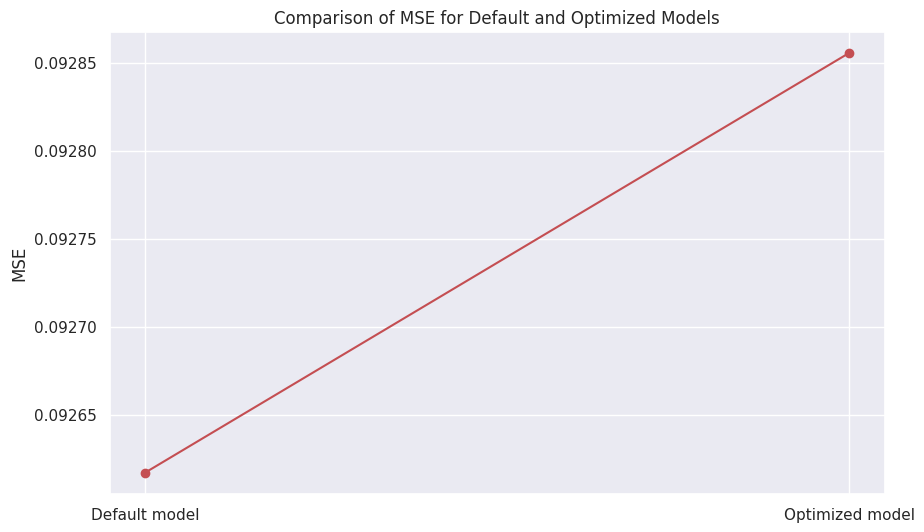

In [ ]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


def objective(trial):

    param = {
        'objective': 'regression',
        'metric': 'l2',
        'boosting_type': 'gbdt',  # тип бустинга (можно попробовать 'dart' или 'goss')
        'num_leaves': trial.suggest_int('num_leaves', 31, 256),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 100),
    }

    model = lgb.LGBMRegressor(**param)

    early_stopping = lgb.early_stopping(stopping_rounds=50, verbose=False)

    model.fit(x_train, y_train,
              eval_set=[(x_valid, y_valid)],
              callbacks=[early_stopping])

    y_pred = model.predict(x_valid)
    mse = mean_squared_error(y_valid, y_pred)

    return mse


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

print("Best parameters:", study.best_params)

best_params = study.best_params
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(x_train, y_train)
y_pred_best = best_model.predict(x_test)
mse_best = mean_squared_error(y_test, y_pred_best)

print(f"Best model MSE on test set: {mse_best}")


import matplotlib.pyplot as plt


default_model = lgb.LGBMRegressor()
default_model.fit(x_train, y_train)
y_pred_default = default_model.predict(x_test)
mse_default = mean_squared_error(y_test, y_pred_default)


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot([1, 2], [mse_default, mse_best], marker='o', color='r')
ax.set_xticks([1, 2])
ax.set_xticklabels(['Default model', 'Optimized model'])
ax.set_ylabel('MSE')
ax.set_title('Comparison of MSE for Default and Optimized Models')
plt.show()


### 3.2. Глубокая оптимизация (1 балл)

Помимо эффективного перебора гиперпараметров, `optuna` предлагает более тонкий контроль над самой процедурой обучения. Улучшите процедуру оптимизации следующим образом:

1. Посмотрите, как в `optuna` устроена запись в хранилища, и добавьте это в пайплайн оптимизации. Без указания БД все запуски оптуны сотрутся, как только закончится сессия. Более того, так можно распараллелить процесс оптимизации на несколько машин
2. Посмотрите, как можно контролировать процесс обучения бустинга при помощи прунера. У библиотечных имплементаций есть уже готовые, их можно использовать пунктом ниже. Для кастомной модели возьмите что-то из `optuna.pruners`. Идея прунера — не обучать бустинг до конца, если по истории видно, что другие бустинги на этом этапе статистически лучше.
3. Добавьте сохранение истории функции потерь и времени обучения в качестве `user_attribute` сразу в `study`. Мы не хотим оптимизировать их напрямую, но они нам понадобится для сравнения моделей в дальнейшем

Добавьте хранилище и юзер атрибуты и посмотрите, ускорилась ли оптимизация с добавлением прунера

[I 2024-12-20 10:50:25,323] A new study created in RDB with name: no-name-b2da5b2a-0b9d-4f20-b657-adf801b65bc2


[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001505 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 756
[LightGBM] [Info] Number of data points in the train set: 18825, number of used features: 155
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Info] Start training from score 0.650359
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

[I 2024-12-20 10:50:26,390] Trial 0 finished with value: 0.08987992152646915 and parameters: {'num_leaves': 46, 'max_depth': 3, 'learning_rate': 0.17944565055685, 'n_estimators': 126, 'subsample': 0.5151637597771818, 'colsample_bytree': 0.9473555450686135, 'min_data_in_leaf': 25}. Best is trial 0 with value: 0.08987992152646915.


[LightGBM] [Warning] min_data_in_leaf is set=75, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=75
[LightGBM] [Warning] min_data_in_leaf is set=75, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=75
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 648
[LightGBM] [Info] Number of data points in the train set: 18825, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=75, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=75
[LightGBM] [Info] Start training from score 0.650359
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

[I 2024-12-20 10:50:27,306] Trial 1 finished with value: 0.08939533327315297 and parameters: {'num_leaves': 210, 'max_depth': 4, 'learning_rate': 0.09612122504478363, 'n_estimators': 453, 'subsample': 0.9671955120776914, 'colsample_bytree': 0.7489542083867808, 'min_data_in_leaf': 75}. Best is trial 1 with value: 0.08939533327315297.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2024-12-20 10:51:33,008] Trial 98 finished with value: 0.09045742138286912 and parameters: {'num_leaves': 206, 'max_depth': 5, 'learning_rate': 0.14981935011671355, 'n_estimators': 226, 'subsample': 0.9496717807290019, 'colsample_bytree': 0.672320021033391, 'min_data_in_leaf': 52}. Best is trial 43 with value: 0.08889202038451668.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2024-12-20 10:51:33,854] Trial 99 finished with value: 0.08980551172540903 and parameters: {'num_leaves': 246, 'max_depth': 3, 'learning_rate': 0.09534049195231996, 'n_estimators': 393, 'subsample': 0.8970872726517424, 'colsample_bytree': 0.7250814967839466, 'min_data_in_leaf': 44}. Best is trial 43 with value: 0.08889202038451668.


Best parameters: {'num_leaves': 148, 'max_depth': 5, 'learning_rate': 0.19194147947915643, 'n_estimators': 263, 'subsample': 0.9558430548069762, 'colsample_bytree': 0.7229268302955221, 'min_data_in_leaf': 57}
[LightGBM] [Warning] min_data_in_leaf is set=57, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=57
[LightGBM] [Warning] min_data_in_leaf is set=57, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=57
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001638 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 680
[LightGBM] [Info] Number of data points in the train set: 18825, number of used features: 117
[LightGBM] [Info] Start training from score 0.650359
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

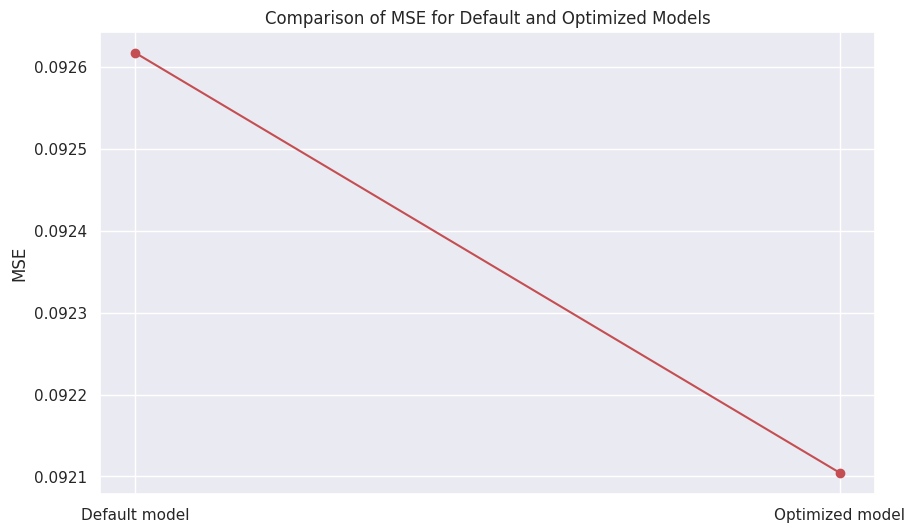

In [ ]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import time


def objective(trial):

    param = {
        'objective': 'regression',
        'metric': 'l2',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 31, 256),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 100),
    }

    model = lgb.LGBMRegressor(**param)


    start_time = time.time()

    early_stopping = lgb.early_stopping(stopping_rounds=50)


    model.fit(x_train, y_train,
              eval_set=[(x_valid, y_valid)],
              callbacks=[early_stopping])


    y_pred = model.predict(x_valid)
    mse = mean_squared_error(y_valid, y_pred)


    end_time = time.time()
    elapsed_time = end_time - start_time


    trial.set_user_attr("loss", mse)
    trial.set_user_attr("training_time", elapsed_time)

    return mse


storage_name = "sqlite:///optuna_study.db"
study = optuna.create_study(direction='minimize', storage=storage_name, load_if_exists=True)


pruner = optuna.pruners.HyperbandPruner()


study.optimize(objective, n_trials=100)

print("Best parameters:", study.best_params)

best_params = study.best_params
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(x_train, y_train)
y_pred_best = best_model.predict(x_test)
mse_best = mean_squared_error(y_test, y_pred_best)

print(f"Best model MSE on test set: {mse_best}")


import matplotlib.pyplot as plt


default_model = lgb.LGBMRegressor()
default_model.fit(x_train, y_train)
y_pred_default = default_model.predict(x_test)
mse_default = mean_squared_error(y_test, y_pred_default)


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot([1, 2], [mse_default, mse_best], marker='o', color='r')
ax.set_xticks([1, 2])
ax.set_xticklabels(['Default model', 'Optimized model'])
ax.set_ylabel('MSE')
ax.set_title('Comparison of MSE for Default and Optimized Models')
plt.show()


### 3.3. Готовые реализации (1 балл)

Библиотек для бустингов существует много, но активно используются лишь три. Ваша задача — попробовать их в деле, посмотреть на их уникальные фишки и понять, что вам нравится больше всего

Возьмите любую из популярных библиотек: <font color='lightblue'>`xgboost`</font>, <font color='lightgreen'>`lightgbm`</font>, <font color='palegoldenrod'>`catboost`</font>.
Ваша задача — взять одну из них, подобрать те же оптимальные параметры, что и выше, плюс что-то, что вам понравилось в них больше всего (может быть абсолютно любая фишка из пунктов выше или что-то, что вы найдете сами, не обязательно эксклюзивное), и сравнить две оптимизированные модели по
- динамике функции потерь (на обучающей и на валидационной выборке)
- времени обучения

<font color='plum'>**Вопрос:** Какая архитектура вам нравится больше всего и почему?</font>

<font color='plum'>**Ответ**: ... </font>

### Бонус. Random Forest (0.5 балла)

Если очень захотеть, оптуна может оптимизировать все, что угодно, даже нейросети. Давайте противопоставим бустингу его злейшего врага — алгоритм Random Forest.

Возьмите реализацию случайного леса из <font color='lightgreen'>`lightgbm`</font>. Посмотрите, какие там есть гиперпараметры, переберите что-либо из них вместе с `max_depth` и `n_estimators`.

Сравните его качество и динамику функции потерь (на обучающей и на валидационной выборке) с таковыми у бустинга и сделайте вывод, а нужен ли Random Forest?

In [ ]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

### 3.4. Бустинг и вероятности (0.5 балла)

С качеством мы более-менее разобрались, но что насчет вероятностей? Постройте калибровочную кривую для вашей лучшей модели бустинга. Насколько хорошо бустинг оценивает вероятности?

In [ ]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚


Постройте также калибровочную кривую для логистической регрессии, сравните их между собой. Проанализируйте полученные результаты.

In [ ]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

## Социализационный бонус. Новогоднее 🎆 (0.5 балла)

Сфотографируйтесь с наряженной новогодней или рождественской ёлкой! Приложите фотографию, опишите свои впечатления, чего вы ждете от нового 2025 года?

Очень надеюсь, что в новом году я найду работу в моем любимом Яндексе и наконец-то сама смогу закрывать все свои потребности и много путешествовать! Пусть в моей жизни останутся мои замечательные друзья, возможно, мой круг общения даже расширится, я открыта к этому. Найти себе успешного айтишника я уже давно не надеюсь, потому что всех претендующих на адекватность давно разобрали, а еще все парни врут, как я убедилась. Ладно, всех грести под одну гребенку и быть обиженкой тоже неправильно. Сама же я выбираю самовлюбленных нарциссов, а тех, кто готов мир положить к моим ногам, отшиваю. Как это лечить? так что я буду продолжать быть здоровой эгоисткой и максимизировать свою полезность от жизни настолько, насколько только смогу. В данной конкретной точке я счастлива, надеюсь, новый год лишь приумножит это счастье, а не разрушит его.
  
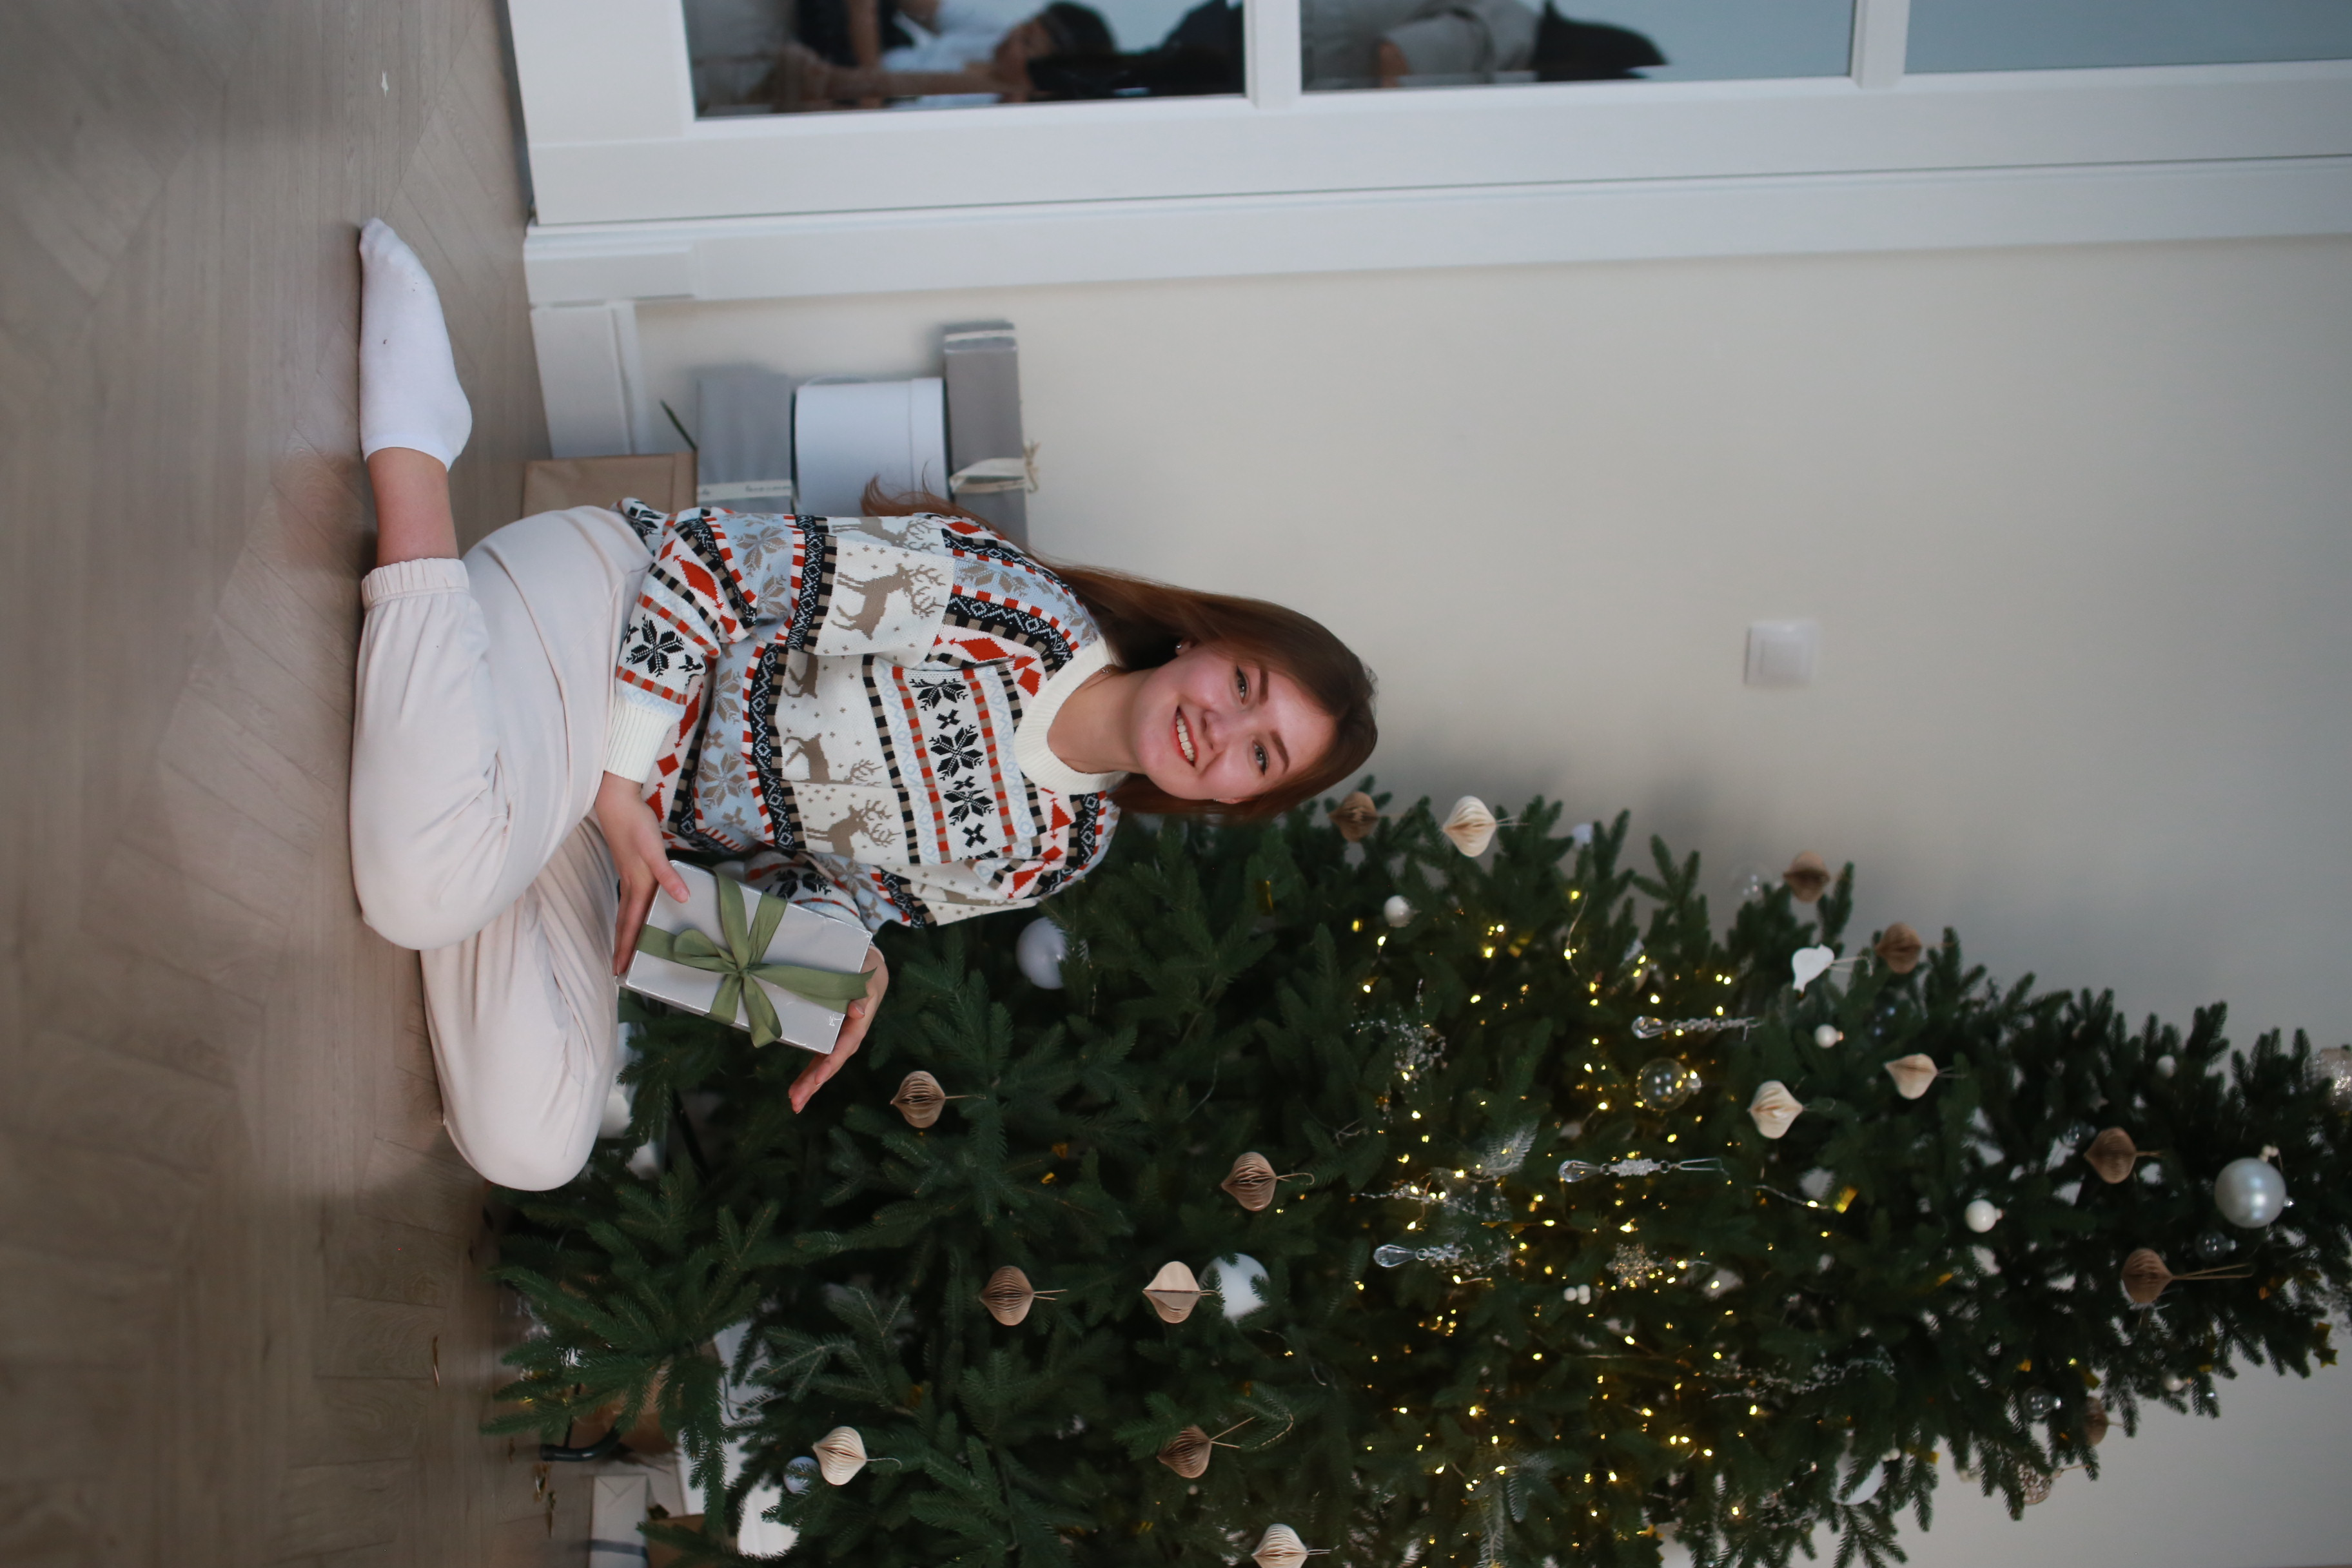

# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚